# Entrenamiento del modelo de Machine Learning con datos reales del prototipo (Arduino)
## Sistema Inteligente de Monitoreo Estructural de Puentes IoT

**Origen de los datos:** ensayo preliminar con Arduino sobre el puente de carton, con vibrador (simula paso de vehiculos) y un mecanismo de jeringas operadas manualmente para subir y bajar un extremo del puente (simula socavacion / asentamiento progresivo)

### Proposito de este notebook

Este notebook toma el archivo de datos reales `data.txt`, generado por el sketch de Arduino durante el ensayo preliminar de laboratorio, y lo utiliza para:

1. Inspeccionar y limpiar los datos crudos.
2. Analizar visualmente el comportamiento de cada sensor durante el ensayo.
3. Definir una etiqueta de estado estructural (`normal`, `alerta`, `critico`) a partir del nivel de asentamiento medido.
4. Dividir los datos en conjuntos de entrenamiento, validacion y prueba evitando fuga de informacion (data leakage), tema critico ya identificado en iteraciones previas del proyecto con datos simulados.
5. Entrenar y comparar modelos baseline de Random Forest usando: solo vibracion, solo distancia/asentamiento, y ambos sensores combinados (fusion multisensor).
6. Entrenar el modelo final en PyTorch (arquitectura 32-16-3, la misma definida para el pipeline simulado) y exportarlo a TorchScript (`.pt`) junto con los parametros de normalizacion (`.json`), listo para ser cargado en la Raspberry Pi.
7. Discutir honestamente las limitaciones de este ensayo (un unico trial continuo) y proponer el protocolo de captura para la siguiente ronda de datos reales.

**Nota importante sobre los archivos generados:** Este notebook exporta los archivos `modelo_puente_real.pt` y `scaler_puente_real.json`, con un sufijo `_real` para distinguirlos del modelo ya entrenado con datos simulados (`modelo_puente.pt` / `scaler_puente.json`). Esto evita sobrescribir el modelo de produccion mientras se evalua si el modelo entrenado con datos reales debe reemplazarlo, complementarlo, o usarse solo como verificacion.


## Etapa 1: Importacion de librerias

Se importan las librerias necesarias para cada parte del flujo de trabajo:

- `pandas` y `numpy`: lectura y manipulacion de los datos tabulares.
- `matplotlib`: visualizacion.
- `scikit-learn`: modelos baseline (Random Forest), normalizacion (`StandardScaler`) y metricas de evaluacion.
- `torch`: definicion, entrenamiento y exportacion a TorchScript del modelo final (MLP).
- `json`: para guardar los parametros del normalizador en un archivo legible por el codigo de inferencia en la Raspberry Pi (`features.py` / `main.py`).

Se fija una semilla aleatoria (`random_state` / `torch.manual_seed`) en cada paso que use aleatoriedad, para que los resultados de este notebook sean reproducibles.


In [64]:
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)

import torch
import torch.nn as nn

warnings.filterwarnings("ignore", category=UserWarning)

SEMILLA = 42
np.random.seed(SEMILLA)
torch.manual_seed(SEMILLA)

print("Version de torch:", torch.__version__)
print("Version de sklearn instalada correctamente.")


Version de torch: 2.9.1+cpu
Version de sklearn instalada correctamente.


## Etapa 2: Carga del archivo de datos crudos

El archivo `data.txt` es la salida directa del sketch de Arduino (formato CSV con comentarios). Tiene tres tipos de lineas que hay que tener en cuenta:

1. Lineas de comentario que empiezan con `#`: mensajes de calibracion (`# [MPU] Offsets...`, `# [DIST] Distancia base...`), la cabecera de columnas, y avisos de lectura invalida del sensor DHT (`# [DHT] LECTURA INVALIDA`). Ninguna de estas lineas contiene una fila de datos util, por lo que se descartan todas usando el parametro `comment='#'` de `pandas.read_csv`.
2. Lineas de datos validas: una fila por cada lectura completa del sensor DHT (cada 2 segundos aproximadamente), que ya contiene el resumen de vibracion (RMS y componentes de frecuencia calculados con el algoritmo de Goertzel sobre la ventana de 256 muestras del MPU6050), la distancia/asentamiento del HC-SR04, la temperatura y humedad del DHT, y el estado del vibrador.
3. El archivo fue generado en un sistema Windows/Arduino IDE, por lo que las lineas terminan en `\r\n` (retorno de carro + salto de linea). `pandas` maneja esto de forma transparente al leer el archivo en modo texto.

Como el archivo no incluye una fila de cabecera utilizable directamente (la cabecera real esta comentada con `#`), se especifican los nombres de columna manualmente, en el mismo orden en que el sketch de Arduino los imprime.


In [65]:
COLUMNAS = [
    "millis",            # tiempo del Arduino/RPi desde el arranque, en milisegundos
    "rms",                # RMS de la aceleracion vertical filtrada (ventana de 256 muestras)
    "freq_dom_hz",        # frecuencia dominante de vibracion detectada (Hz)
    "f2hz", "f5hz", "f10hz", "f20hz", "f35hz",  # energia (Goertzel) en bandas de frecuencia fijas
    "distancia_cm",       # distancia HC-SR04 suavizada (media movil)
    "asentamiento_cm",    # distancia_cm menos la distancia base calibrada al inicio
    "temperatura_c",      # temperatura DHT (promedio movil)
    "humedad_pct",        # humedad relativa DHT (promedio movil)
    "vibrador",           # estado del motor vibrador de prueba: "ON" / "OFF"
]

RUTA_DATOS = "D:\IRAN\PycharmProjects\IoT\data.txt"

df = pd.read_csv(RUTA_DATOS, comment="#", names=COLUMNAS)

print("Filas leidas:", len(df))
df.head(10)


Filas leidas: 852


<>:13: SyntaxWarning: invalid escape sequence '\I'
<>:13: SyntaxWarning: invalid escape sequence '\I'
C:\Users\IRAN\AppData\Local\Temp\ipykernel_23832\275264716.py:13: SyntaxWarning: invalid escape sequence '\I'
  RUTA_DATOS = "D:\IRAN\PycharmProjects\IoT\data.txt"


,millis,rms,freq_dom_hz,f2hz,f5hz,f10hz,f20hz,f35hz,distancia_cm,asentamiento_cm,temperatura_c,humedad_pct,vibrador
0,5703,0.143627,20.0,0.007007,0.008119,0.010903,0.053371,0.015593,11.086,-0.105,26.00,10.00,ON
1,7989,0.085629,33.0,0.001326,0.003039,0.001098,0.014059,0.005729,11.245,0.053,26.00,9.00,ON
2,9989,0.083359,34.0,0.002507,0.002053,0.007229,0.009061,0.010731,11.088,-0.103,26.00,8.67,ON
3,12023,0.085521,34.0,0.003184,0.004228,0.007599,0.010273,0.007912,11.140,-0.052,25.95,9.25,ON
4,14390,0.078940,33.0,0.002204,0.001867,0.003569,0.008346,0.005051,11.074,-0.117,25.94,9.40,OFF
5,16390,0.001245,7.0,0.000161,0.000127,0.000054,0.000100,0.000027,10.978,-0.214,25.92,9.40,OFF
6,18424,0.001310,12.0,0.000204,0.000148,0.000130,0.000130,0.000015,11.219,0.028,25.90,9.40,OFF
7,20789,0.086087,33.0,0.002055,0.005301,0.005847,0.006517,0.005535,10.981,-0.210,25.86,9.60,ON
8,22789,0.085257,34.0,0.003547,0.003636,0.004978,0.006330,0.013223,10.891,-0.300,25.86,9.20,ON
9,24822,0.083725,34.0,0.002838,0.004445,0.005576,0.009868,0.008232,10.881,-0.310,25.84,9.60,ON


In [66]:
# Resumen general del dataframe: tipos de dato y estadisticos descriptivos.
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 852 entries, 0 to 851
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   millis           852 non-null    int64  
 1   rms              852 non-null    float64
 2   freq_dom_hz      852 non-null    float64
 3   f2hz             852 non-null    float64
 4   f5hz             852 non-null    float64
 5   f10hz            852 non-null    float64
 6   f20hz            852 non-null    float64
 7   f35hz            852 non-null    float64
 8   distancia_cm     852 non-null    float64
 9   asentamiento_cm  852 non-null    float64
 10  temperatura_c    852 non-null    float64
 11  humedad_pct      852 non-null    float64
 12  vibrador         852 non-null    object 
dtypes: float64(11), int64(1), object(1)
memory usage: 86.7+ KB


In [67]:
df.describe()


,millis,rms,freq_dom_hz,f2hz,f5hz,f10hz,f20hz,f35hz,distancia_cm,asentamiento_cm,temperatura_c,humedad_pct
count,8.520000e+02,852.000000,852.000000,852.000000,852.000000,852.000000,852.000000,852.000000,852.000000,852.000000,852.000000,852.000000
mean,9.304198e+05,0.035853,23.857981,0.001417,0.001950,0.001654,0.003774,0.001894,8.783555,-2.407816,25.262007,16.367981
std,5.284497e+05,0.027719,12.759173,0.001636,0.001951,0.001891,0.003940,0.002528,1.210747,1.210729,0.156337,1.715651
min,5.703000e+03,0.000910,1.000000,0.000023,0.000013,0.000013,0.000004,0.000001,7.150000,-4.041000,25.060000,8.670000
25%,4.787130e+05,0.002039,8.000000,0.000304,0.000318,0.000260,0.000155,0.000034,8.073500,-3.118500,25.180000,15.800000
50%,9.326040e+05,0.039901,32.000000,0.000974,0.001561,0.001103,0.003322,0.000904,8.721500,-2.470000,25.220000,16.800000
75%,1.386496e+06,0.050240,33.000000,0.001836,0.003068,0.002351,0.006057,0.002596,9.563250,-1.627750,25.300000,17.400000
max,1.840389e+06,0.143627,35.000000,0.015767,0.024375,0.014454,0.053371,0.015593,11.247000,0.055000,26.000000,19.200000


## Etapa 3: Preparacion de la variable temporal

La columna `millis` viene en milisegundos desde el arranque del programa. Para los graficos y para razonar sobre el ensayo en unidades comprensibles, se crea una columna `t_s` en segundos, y se confirma que el dataframe esta ordenado cronologicamente (esto es indispensable para todo lo que sigue: ninguna division en train/val/test puede mezclar el orden temporal real del ensayo).


In [68]:
df["t_s"] = df["millis"] / 1000.0
df = df.sort_values("t_s").reset_index(drop=True)

duracion_total_s = df["t_s"].max() - df["t_s"].min()
print(f"Duracion total del ensayo: {duracion_total_s:.1f} s "
      f"(~{duracion_total_s/60:.1f} minutos)")
print(f"Numero de filas (lecturas): {len(df)}")
print(f"Intervalo promedio entre filas: {df['t_s'].diff().mean():.2f} s")


Duracion total del ensayo: 1834.7 s (~30.6 minutos)
Numero de filas (lecturas): 852
Intervalo promedio entre filas: 2.16 s


## Etapa 4: Analisis exploratorio (EDA)

Antes de definir cualquier etiqueta o entrenar cualquier modelo, es indispensable observar la forma de los datos. Se generan tres vistas:

1. **Vibracion (RMS) en el tiempo**, coloreada segun el estado del vibrador (ON/OFF), para confirmar que el ciclo de encendido/apagado del motor (10 s encendido, 5 s apagado, segun `main.py`) se refleja claramente en la señal.
2. **Asentamiento (HC-SR04) en el tiempo**, para observar como evoluciono el desnivel manual durante el ensayo.
3. **Temperatura y humedad en el tiempo**, como contexto ambiental (recordando que, segun el diseño del proyecto, estas variables NO se usan para clasificar el estado estructural, solo como dato informativo en el dashboard).


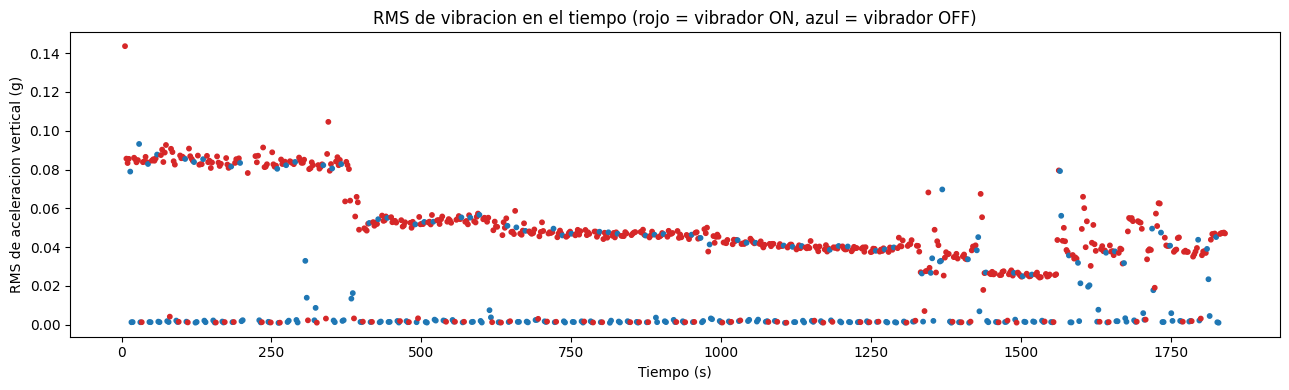

In [69]:
fig, ax = plt.subplots(figsize=(13, 4))
colores_vib = df["vibrador"].map({"ON": "tab:red", "OFF": "tab:blue"})
ax.scatter(df["t_s"], df["rms"], c=colores_vib, s=10)
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("RMS de aceleracion vertical (g)")
ax.set_title("RMS de vibracion en el tiempo (rojo = vibrador ON, azul = vibrador OFF)")
plt.tight_layout()
plt.show()


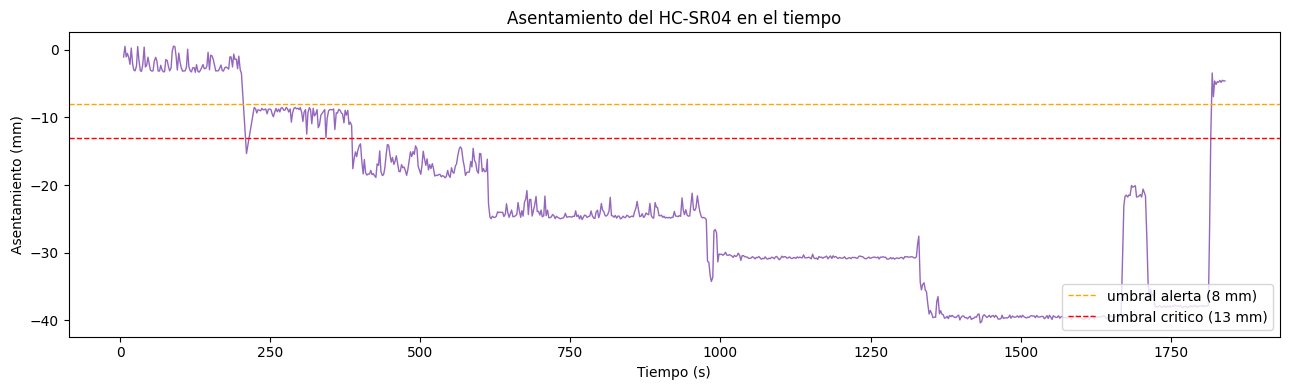

In [70]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df["t_s"], df["asentamiento_cm"] * 10.0, color="tab:purple", linewidth=1)
ax.axhline(-8, color="orange", linestyle="--", linewidth=1, label="umbral alerta (8 mm)")
ax.axhline(-13, color="red", linestyle="--", linewidth=1, label="umbral critico (13 mm)")
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Asentamiento (mm)")
ax.set_title("Asentamiento del HC-SR04 en el tiempo")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


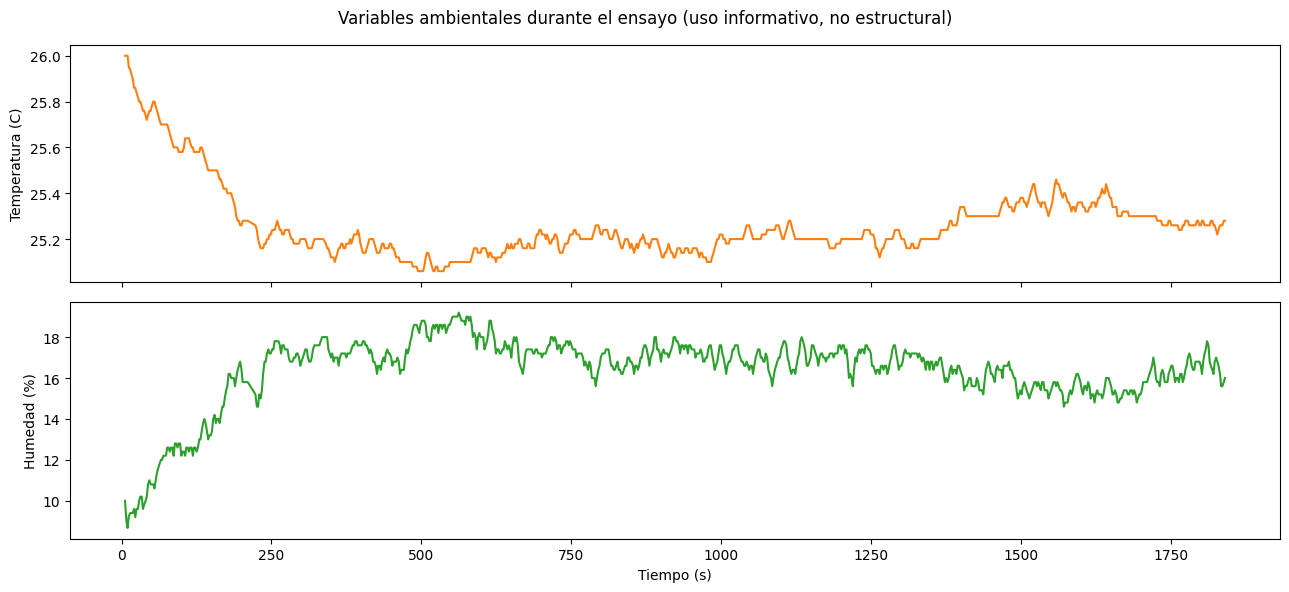

In [71]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].plot(df["t_s"], df["temperatura_c"], color="tab:orange")
axes[0].set_ylabel("Temperatura (C)")
axes[1].plot(df["t_s"], df["humedad_pct"], color="tab:green")
axes[1].set_ylabel("Humedad (%)")
axes[1].set_xlabel("Tiempo (s)")
fig.suptitle("Variables ambientales durante el ensayo (uso informativo, no estructural)")
plt.tight_layout()
plt.show()


**Lectura de los graficos anteriores:**

- El RMS de vibracion alterna claramente entre dos regimenes (aproximadamente 0.08-0.09 g cuando el vibrador esta encendido, y cercano a 0 cuando esta apagado), siguiendo el ciclo de 10 segundos ON / 5 segundos OFF programado en `main.py`. El valor maximo de RMS observado en todo el ensayo es de aproximadamente 0.14 g.
- El asentamiento sigue un **descenso por escalones**, no un salto unico ni un proceso ciclico: el equipo bajo el extremo del puente con la jeringa en varias etapas sucesivas (aproximadamente 0 mm, despues ~9 mm, ~14 mm, ~17 mm, ~20 mm, ~24 mm, ~30 mm, ~36 mm, hasta cerca de 40 mm), deteniendose un tiempo en cada profundidad, probablemente para que el sensor se estabilizara y se pudieran tomar varias lecturas por nivel. En los ultimos minutos del ensayo el asentamiento varia rapidamente hacia arriba y abajo, consistente con que el equipo estuvo subiendo y bajando la jeringa para observar la recuperacion, y finalmente el valor regresa cerca de la posicion original. Este patron se examina con mas detalle justo despues de esta seccion.
- Temperatura y humedad varian de forma lenta y suave, sin relacion aparente con el estado estructural; esto confirma que su rol debe limitarse a informacion ambiental, tal como esta definido en el diseño del sistema.

**Consecuencia metodologica importante:** el vibrador (RMS) y el asentamiento evolucionan de forma practicamente independiente en este ensayo. El vibrador se enciende y apaga por temporizador, sin relacion con la profundidad alcanzada por la jeringa de asentamiento. Esto sera relevante mas adelante al interpretar si la fusion de sensores aporta valor en este dataset especifico.


### Mirando el asentamiento con mas detalle: el patron de descenso por escalones

El grafico anterior muestra la tendencia general, pero para entender bien como se uso la jeringa durante el ensayo conviene dividir el tiempo en bloques y revisar el valor minimo, maximo y promedio de asentamiento en cada bloque. Esto permite ver los escalones de profundidad que no se distinguen facilmente a simple vista en un grafico de 1840 segundos completos.


In [72]:
TAMANIO_BLOQUE = 50  # filas por bloque (~100 segundos cada uno)

df["asentamiento_mm"] = df["asentamiento_cm"].abs() * 10.0

resumen_bloques = []
for inicio in range(0, len(df), TAMANIO_BLOQUE):
    bloque = df.iloc[inicio:inicio + TAMANIO_BLOQUE]
    resumen_bloques.append({
        "t_inicio_s": bloque["t_s"].min(),
        "t_fin_s": bloque["t_s"].max(),
        "asentamiento_min_mm": bloque["asentamiento_mm"].min(),
        "asentamiento_max_mm": bloque["asentamiento_mm"].max(),
        "asentamiento_promedio_mm": bloque["asentamiento_mm"].mean(),
    })

df_resumen_bloques = pd.DataFrame(resumen_bloques)
df_resumen_bloques.round(2)


,t_inicio_s,t_fin_s,asentamiento_min_mm,asentamiento_max_mm,asentamiento_promedio_mm
0,5.70,110.39,0.16,3.26,2.02
1,112.39,233.99,0.10,15.34,3.37
2,236.02,342.79,8.52,12.97,9.31
3,344.82,449.59,8.74,18.88,13.95
4,451.59,556.02,14.21,18.93,17.29
5,558.39,662.79,14.36,25.00,20.34
6,664.82,769.59,20.83,25.12,24.12
7,771.59,876.02,21.83,25.02,24.35
8,878.39,982.79,21.21,33.34,24.60
9,984.82,1089.59,26.59,34.28,30.54


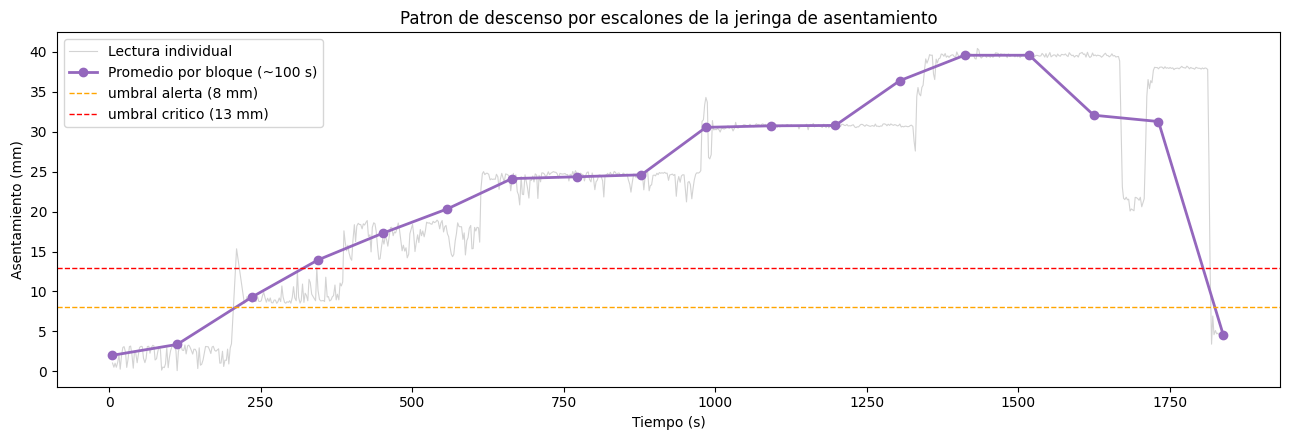

In [73]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(df["t_s"], df["asentamiento_mm"], color="lightgray", linewidth=0.8, label="Lectura individual")
ax.plot(df_resumen_bloques["t_inicio_s"], df_resumen_bloques["asentamiento_promedio_mm"],
        color="tab:purple", marker="o", linewidth=2, label="Promedio por bloque (~100 s)")
ax.axhline(8, color="orange", linestyle="--", linewidth=1, label="umbral alerta (8 mm)")
ax.axhline(13, color="red", linestyle="--", linewidth=1, label="umbral critico (13 mm)")
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Asentamiento (mm)")
ax.set_title("Patron de descenso por escalones de la jeringa de asentamiento")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


**Lectura de este grafico:** la linea morada (promedio por bloque) sube en forma de escalera durante la mayor parte del ensayo: el equipo bajo el extremo del puente con la jeringa en varias etapas sucesivas, deteniendose un tiempo en cada profundidad antes de seguir bajando. Recien en los ultimos bloques (despues de los 1600 segundos aproximadamente) aparece una zona de oscilacion mas brusca hacia arriba y abajo, y finalmente el asentamiento regresa cerca de 0 mm en los ultimos segundos.

**Por que esto es relevante para el balance de clases (Etapa 7):** el umbral de critico (13 mm) queda cerca del comienzo de este recorrido. Como el equipo continuo bajando la jeringa hasta casi 40 mm, y el tiempo total del ensayo se reparte entre todos los escalones, la mayor parte de las filas terminan ubicadas en profundidades por encima de 13 mm, es decir, en la clase `critico`. Este punto se retoma con numeros concretos despues de definir la etiqueta de estado.


## Etapa 5: Matriz de correlacion entre variables numericas

Se calcula la correlacion lineal entre todas las variables numericas para detectar relaciones evidentes (por ejemplo, entre `distancia_cm` y `asentamiento_cm`, que por definicion estan relacionadas casi linealmente, ya que `asentamiento_cm = distancia_cm - distancia_base`) y para revisar si alguna variable ambiental se correlaciona de forma espuria con las variables estructurales.


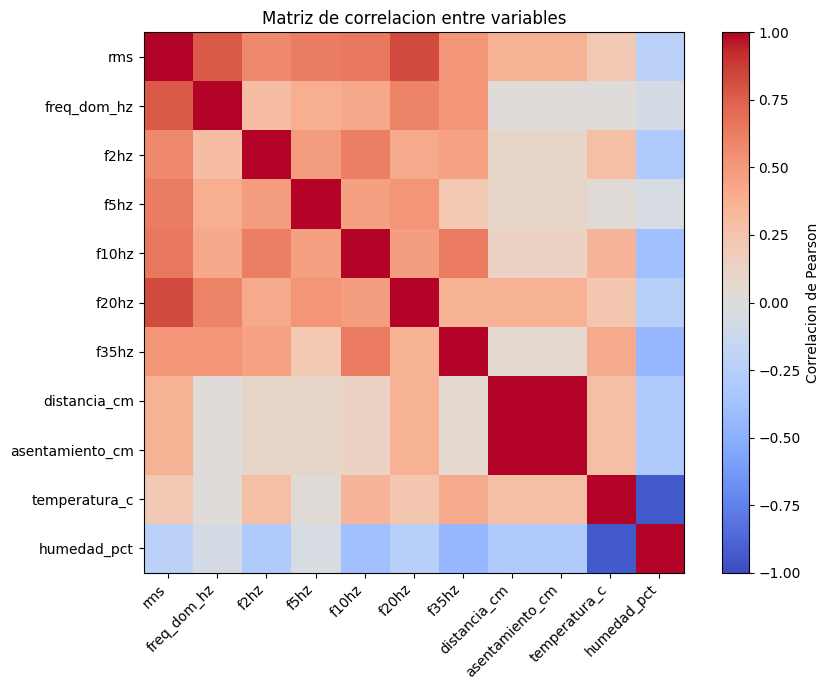

In [74]:
columnas_numericas = [
    "rms", "freq_dom_hz", "f2hz", "f5hz", "f10hz", "f20hz", "f35hz",
    "distancia_cm", "asentamiento_cm", "temperatura_c", "humedad_pct",
]
matriz_corr = df[columnas_numericas].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(matriz_corr, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(columnas_numericas)))
ax.set_xticklabels(columnas_numericas, rotation=45, ha="right")
ax.set_yticks(range(len(columnas_numericas)))
ax.set_yticklabels(columnas_numericas)
fig.colorbar(im, ax=ax, label="Correlacion de Pearson")
ax.set_title("Matriz de correlacion entre variables")
plt.tight_layout()
plt.show()


Como se esperaba, `distancia_cm` y `asentamiento_cm` estan casi perfectamente correlacionadas (son la misma medicion fisica, una es un desplazamiento constante de la otra). Esto se tendra en cuenta en la Etapa 9, al discutir la circularidad entre la etiqueta y las variables del sensor de distancia.


## Etapa 6: Por que este dataset es distinto al dataset simulado (y por que importa)

En las iteraciones previas del proyecto, el dataset de entrenamiento fue **simulado**, y estaba compuesto por muchos **eventos independientes** (trials), cada uno con su propia variabilidad de base. Esto permitio dividir entrenamiento/validacion/prueba por evento completo, evitando que el modelo viera fragmentos de un mismo evento en mas de un conjunto.

El archivo `data.txt` analizado en este notebook es **un unico ensayo continuo real**, de aproximadamente 31 minutos, registrado con el sketch de Arduino. Esto tiene dos consecuencias directas sobre la metodologia:

1. **Autocorrelacion temporal:** dos filas consecutivas (separadas por ~2 segundos) describen un estado fisico casi identico (la profundidad de la jeringa de asentamiento no cambia de un instante a otro). Si se dividiera el dataset al azar (mezclando filas sin respetar el tiempo) en entrenamiento y prueba, filas casi identicas terminarian en conjuntos distintos, y el modelo obtendria una precision artificialmente alta que no reflejaria su capacidad real de generalizar a una posicion de asentamiento nueva. Este es el mismo tipo de fuga de datos por ventaneo que ya se identifico y corrigio en el pipeline simulado, aplicado ahora al caso de una serie temporal real.

2. **Un solo trial, no multiples eventos:** no existen aqui "varios puentes" o "varias corridas" independientes que permitan una division por evento como en el dataset simulado. Solo existe el avance del tiempo dentro de esta unica corrida.

**Decision de division adoptada en este notebook:** en lugar de dividir por evento (no aplicable, solo hay uno) o dividir aleatoriamente por fila (genera fuga), se identifican **segmentos temporales contiguos** del ensayo en los que el estado estructural (ver Etapa 7) permanece constante, y cada segmento se divide cronologicamente en train/val/test, dejando un margen ("gap") de filas sin usar entre cada division para reducir la autocorrelacion entre el final de un conjunto y el inicio del siguiente. Esta estrategia se explica en detalle en la Etapa 8.

**Limitacion que debe quedar explicita:** con un unico ensayo, ninguna estrategia de division elimina por completo el riesgo de autocorrelacion; solo lo reduce. La recomendacion para la siguiente ronda de captura de datos reales es repetir el ensayo varias veces, de forma independiente (subiendo y bajando la jeringa en distintos momentos, con distinto orden de encendido del vibrador), para poder aplicar la misma division por evento ya validada con los datos simulados. Esto se retoma en las conclusiones.


## Etapa 7: Definicion de la etiqueta de estado estructural

El diseño del sistema (documentado en el firmware `actuadores.py`) define tres estados segun el nivel de asentamiento medido:

| Estado    | Asentamiento       |
|-----------|---------------------|
| Normal    | menor a 8 mm         |
| Alerta    | entre 8 mm y 13 mm    |
| Critico   | mayor o igual a 13 mm |

Estos umbrales se aplican aqui sobre el **valor absoluto** del asentamiento (`asentamiento_cm` convertido a milimetros), porque lo relevante para la integridad estructural es la magnitud del desnivel, sin importar si el HC-SR04 registra un alejamiento o un acercamiento respecto a la base calibrada.

Los umbrales se definen como constantes configurables al inicio del bloque de codigo, para que puedan ajustarse facilmente si el equipo decide calibrarlos de otra forma en la maqueta final (por ejemplo, si el rango fisico del mecanismo de asentamiento de la maqueta definitiva difiere del rango alcanzado con la jeringa en este ensayo de carton, que llego hasta casi 40 mm; ver el analisis de sensibilidad justo despues de esta seccion).

**Nota sobre el RMS de vibracion:** el diseño tambien define umbrales de RMS (alerta entre 0.23 g y 0.27 g, critico sobre 0.27 g). En este ensayo, el RMS maximo registrado fue de aproximadamente 0.14 g (ver Etapa 4), es decir, el motor vibrador usado en el prototipo de carton nunca alcanzo el umbral de alerta por vibracion. Por esta razon, en este dataset especifico, la etiqueta de estado estructural se construye exclusivamente a partir del asentamiento, que es la unica variable que efectivamente recorrio los tres estados durante el ensayo. Esto no es un error: simplemente refleja que este ensayo preliminar fue diseñado para validar el sensor de desnivel, no para generar vibraciones de gran amplitud.


In [75]:
UMBRAL_ALERTA_MM = 8.0
UMBRAL_CRITICO_MM = 13.0

df["asentamiento_mm"] = df["asentamiento_cm"].abs() * 10.0

def etiquetar_estado(asentamiento_mm):
    if asentamiento_mm < UMBRAL_ALERTA_MM:
        return "normal"
    elif asentamiento_mm < UMBRAL_CRITICO_MM:
        return "alerta"
    else:
        return "critico"

df["estado"] = df["asentamiento_mm"].apply(etiquetar_estado)

print("Distribucion de clases en todo el ensayo:")
print(df["estado"].value_counts())
print()
print("Proporcion de cada clase:")
print((df["estado"].value_counts(normalize=True) * 100).round(1))


Distribucion de clases en todo el ensayo:
estado
critico    671
normal     104
alerta      77
Name: count, dtype: int64

Proporcion de cada clase:
estado
critico    78.8
normal     12.2
alerta      9.0
Name: proportion, dtype: float64


Como se anticipo en la Etapa 4, la clase `critico` domina el ensayo (alrededor del 79% de las filas). La razon ya se observo en el grafico de escalones: el equipo recorrio profundidades con la jeringa desde 0 mm hasta casi 40 mm, y el umbral de `critico` (13 mm) queda apenas a un tercio de ese recorrido. Como el ensayo reparte un tiempo parecido entre cada escalon de profundidad, la mayoria de las filas terminan en profundidades superiores a 13 mm, simplemente porque esa zona ocupa la mayor parte del rango fisico que alcanzo la jeringa. Esto es un **desbalance de clases real**, no un error de etiquetado, y se debe manejar explicitamente al entrenar los modelos (ponderacion de clases) y al interpretar las metricas (usar F1-macro ademas de accuracy, ya que accuracy puede ser engañosamente alto con clases desbalanceadas).


### Etapa 7 (continuacion): que pasaria si se cambiaran los umbrales de 8 mm / 13 mm

Antes de continuar conviene responder una pregunta natural: ¿que pasaria con el balance de clases si se usaran otros umbrales en lugar de 8 mm / 13 mm?

La siguiente tabla prueba algunas alternativas sobre los mismos datos, unicamente para ilustrar el efecto. **Esto no significa que se deba cambiar el umbral real**: el umbral de 8 mm / 13 mm representa una decision de ingenieria sobre cuanto asentamiento es realmente peligroso para la estructura, no un parametro que se deba ajustar para que el dataset se vea mas balanceado. Cambiarlo unicamente para emparejar las clases equivaldria a redefinir, sin base tecnica, que tan grave es un asentamiento de 18 mm.


In [76]:
def etiquetar_con_umbrales(asentamiento_mm, umbral_alerta, umbral_critico):
    if asentamiento_mm < umbral_alerta:
        return "normal"
    elif asentamiento_mm < umbral_critico:
        return "alerta"
    else:
        return "critico"

opciones_umbral = [
    ("Umbral de diseno (8 / 13 mm)", 8.0, 13.0),
    ("Umbral mas alto (15 / 25 mm)", 15.0, 25.0),
    ("Umbral aun mas alto (20 / 30 mm)", 20.0, 30.0),
]

filas_comparacion = []
for nombre, u_alerta, u_critico in opciones_umbral:
    etiquetas_prueba = df["asentamiento_mm"].apply(
        lambda mm: etiquetar_con_umbrales(mm, u_alerta, u_critico)
    )
    conteo = etiquetas_prueba.value_counts()
    filas_comparacion.append({
        "umbrales": nombre,
        "normal": int(conteo.get("normal", 0)),
        "alerta": int(conteo.get("alerta", 0)),
        "critico": int(conteo.get("critico", 0)),
    })

pd.DataFrame(filas_comparacion)


,umbrales,normal,alerta,critico
0,Umbral de diseno (8 / 13 mm),104,77,671
1,Umbral mas alto (15 / 25 mm),193,278,381
2,Umbral aun mas alto (20 / 30 mm),288,197,367


Subir los umbrales reparte mejor las clases, porque el rango real que alcanzo la jeringa en este ensayo (hasta ~40 mm) es mayor al rango para el que estaba pensado el umbral original. Esto confirma dos cosas:

1. El desbalance de clases de este ensayo es consecuencia directa de cuanto se uso la jeringa, no un error en el umbral de diseño.
2. La forma correcta de obtener un dataset mas balanceado en la siguiente ronda de pruebas no es subir el umbral, sino pasar mas tiempo de la prueba en profundidades de 0 a 13 mm (normal y alerta) y menos tiempo sostenido por encima de 13 mm, o bien acotar deliberadamente cuanto se empuja la jeringa durante la captura de datos.

Por estas razones, este notebook mantiene el umbral de diseño (8 mm / 13 mm) para todo el entrenamiento que sigue, y maneja el desbalance de clases con `class_weight="balanced"` (Random Forest) y con los pesos de clase en la funcion de perdida (red neuronal, Etapa 13), en lugar de alterar el significado del umbral.


## Etapa 8: Identificacion de segmentos temporales y division en train / validacion / prueba

Como se explico en la Etapa 6, no es posible dividir este ensayo por "evento", porque solo hay uno. En su lugar, se identifican tramos contiguos del ensayo donde la etiqueta `estado` no cambia (a estos tramos se les llama aqui "segmentos"). Cada segmento representa una fase fisica distinta del ensayo: por ejemplo, los primeros ~93 registros corresponden a la fase inicial en estado `normal`, antes de que se empezara a accionar la jeringa de asentamiento.

Se descartan los segmentos de menos de 5 filas (`MIN_FILAS_SEGMENTO`): corresponden a transiciones de un solo instante entre dos estados, producto del momento exacto en que el asentamiento cruzo un umbral, y no representan una fase estable del ensayo.

Cada segmento valido se divide internamente, de forma cronologica, en 70% entrenamiento / 15% validacion / 15% prueba, dejando un margen (`GAP_FILAS`) de filas sin usar entre cada division. Este margen reduce la autocorrelacion entre el final de un conjunto y el inicio del siguiente: dos filas separadas por varios registros (es decir, varios segundos) son menos parecidas entre si que dos filas consecutivas.

Finalmente, los fragmentos de entrenamiento de todos los segmentos se concatenan para formar el conjunto de entrenamiento completo, y lo mismo para validacion y prueba.


In [77]:
MIN_FILAS_SEGMENTO = 5
GAP_FILAS = 5  # filas de margen (~10 s) descartadas entre cada division, dentro de cada segmento

# Un nuevo segmento comienza cada vez que la etiqueta "estado" cambia respecto a la fila anterior.
id_segmento = (df["estado"] != df["estado"].shift()).cumsum()
segmentos = [grupo.reset_index(drop=True) for _, grupo in df.groupby(id_segmento)]

print(f"Segmentos detectados en total: {len(segmentos)}")
for seg in segmentos:
    print(f"  estado={seg['estado'].iloc[0]:8s}  filas={len(seg):4d}  "
          f"t=({seg['t_s'].min():8.2f} s -> {seg['t_s'].max():8.2f} s)")

segmentos_validos = [seg for seg in segmentos if len(seg) >= MIN_FILAS_SEGMENTO]
print()
print(f"Segmentos validos (>= {MIN_FILAS_SEGMENTO} filas) usados para el entrenamiento: {len(segmentos_validos)}")


Segmentos detectados en total: 6
  estado=normal    filas=  93  t=(    5.70 s ->   201.99 s)
  estado=critico   filas=   1  t=(  210.42 s ->   210.42 s)
  estado=alerta    filas=  76  t=(  223.22 s ->   385.59 s)
  estado=critico   filas= 670  t=(  387.59 s ->  1814.79 s)
  estado=alerta    filas=   1  t=( 1816.82 s ->  1816.82 s)
  estado=normal    filas=  11  t=( 1819.19 s ->  1840.39 s)

Segmentos validos (>= 5 filas) usados para el entrenamiento: 4


In [78]:
def dividir_segmento(bloque, frac_train=0.70, frac_val=0.15, gap=GAP_FILAS):
    '''Divide un segmento temporal en train/val/test de forma cronologica,
    dejando un margen (gap) de filas sin usar entre cada division.
    Para segmentos muy pequeños, el margen se reduce automaticamente
    para no perder por completo la validacion o la prueba.'''
    n = len(bloque)
    gap_efectivo = min(gap, max(1, n // 10))

    n_train = int(round(n * frac_train))
    n_val = int(round(n * frac_val))

    inicio_val = n_train + gap_efectivo
    fin_val = inicio_val + n_val
    inicio_test = fin_val + gap_efectivo

    if inicio_test >= n:
        # El segmento es demasiado pequeño para dos margenes completos:
        # se elimina el margen y se garantiza al menos una fila en val y test.
        inicio_val = n_train
        fin_val = inicio_val + max(1, n_val)
        inicio_test = fin_val

    return bloque.iloc[:n_train], bloque.iloc[inicio_val:fin_val], bloque.iloc[inicio_test:]


partes_train, partes_val, partes_test = [], [], []
for seg in segmentos_validos:
    tr, va, te = dividir_segmento(seg)
    partes_train.append(tr)
    partes_val.append(va)
    partes_test.append(te)

df_train = pd.concat(partes_train).reset_index(drop=True)
df_val = pd.concat(partes_val).reset_index(drop=True)
df_test = pd.concat(partes_test).reset_index(drop=True)

print("Tamaño de cada conjunto:")
print(f"  Entrenamiento: {len(df_train)} filas")
print(f"  Validacion:    {len(df_val)} filas")
print(f"  Prueba:        {len(df_test)} filas")


Tamaño de cada conjunto:
  Entrenamiento: 595 filas
  Validacion:    127 filas
  Prueba:        98 filas


In [79]:
print("Distribucion de clases por conjunto:\n")
for nombre, conjunto in [("Entrenamiento", df_train), ("Validacion", df_val), ("Prueba", df_test)]:
    print(f"{nombre}:")
    print(conjunto["estado"].value_counts())
    print()


Distribucion de clases por conjunto:

Entrenamiento:
estado
critico    469
normal      73
alerta      53
Name: count, dtype: int64

Validacion:
estado
critico    100
normal      16
alerta      11
Name: count, dtype: int64

Prueba:
estado
critico    91
normal      5
alerta      2
Name: count, dtype: int64



Los tres conjuntos contienen ejemplos de las tres clases, lo cual es indispensable para poder evaluar el modelo de forma significativa en cada estado. Sin embargo, el conjunto de prueba contiene muy pocos ejemplos de `normal` (5) y `alerta` (2): esto es consecuencia directa de que estos dos estados ocuparon una porcion pequeña y breve del ensayo. Las metricas sobre estas clases en el conjunto de prueba deben interpretarse con cautela por el tamaño muestral reducido, y este punto se retoma en las conclusiones.


## Etapa 9: Seleccion de variables y advertencia sobre circularidad etiqueta-sensor

Se definen tres conjuntos de variables (features), replicando la comparacion ya usada en el pipeline simulado para argumentar el valor de la fusion de sensores:

- **Solo vibracion (MPU6050):** `rms`, `freq_dom_hz`, `f2hz`, `f5hz`, `f10hz`, `f20hz`, `f35hz`.
- **Solo distancia (HC-SR04):** `distancia_cm`, `asentamiento_cm`.
- **Multisensor:** la union de los dos conjuntos anteriores.

Las columnas `temperatura_c`, `humedad_pct` y `vibrador` se excluyen deliberadamente de los tres conjuntos:

- Temperatura y humedad, por diseño del proyecto, son variables de contexto ambiental, no variables estructurales (evita la fuga por temperatura/humedad ya identificada en el pipeline simulado).
- `vibrador` se excluye porque es una señal de control del banco de pruebas (indica si el motor de prueba esta encendido), no una lectura de un sensor del sistema real. En el sistema final, la Raspberry Pi no tiene una forma de "saber" si hay un vehiculo pasando en ese instante exacto salvo a traves de lo que el propio MPU6050 mide; usar la variable `vibrador` como entrada del modelo seria usar informacion que no existira en el momento de la inferencia real.

**Advertencia metodologica importante, antes de ver resultados:** la etiqueta `estado` definida en la Etapa 7 se calculo directamente a partir de `asentamiento_cm`. Esto significa que el conjunto "solo distancia" tiene, por construccion, casi toda la informacion necesaria para reconstruir la etiqueta de forma casi perfecta: no se trata de que el modelo "aprenda" una relacion compleja, sino de que esta recuperando el mismo umbral que se uso para generar la etiqueta. Esto es exactamente el mismo problema de correlacion artificial entre una variable y la etiqueta que ya se identifico y corrigio en el dataset simulado (alli se solucionaba agregando variabilidad de base entre eventos independientes). En este ensayo real de un solo trial no es posible aplicar esa misma correccion, porque no existen eventos independientes con bases distintas.

Por esta razon, el resultado del modelo "solo distancia" en este notebook **no debe leerse como una medida honesta del poder predictivo del HC-SR04 en un escenario nuevo**, sino como una verificacion de que el HC-SR04 reproduce correctamente la regla de umbral ya implementada directamente en el firmware (`actuadores.py`). La pregunta realmente informativa que este ensayo si puede responder es otra: **¿el MPU6050 (vibracion), por si solo, contiene señal util para distinguir el estado de asentamiento?** Esa es la comparacion que de verdad aporta informacion nueva en este dataset, y se analiza con atencion en la Etapa 11.


In [80]:
VARIABLES_VIBRACION = ["rms", "freq_dom_hz", "f2hz", "f5hz", "f10hz", "f20hz", "f35hz"]
VARIABLES_DISTANCIA = ["distancia_cm", "asentamiento_cm"]
VARIABLES_MULTISENSOR = VARIABLES_VIBRACION + VARIABLES_DISTANCIA

MAPA_CLASES = {"normal": 0, "alerta": 1, "critico": 2}
NOMBRES_CLASES = ["normal", "alerta", "critico"]

print("Variables de vibracion:  ", VARIABLES_VIBRACION)
print("Variables de distancia:  ", VARIABLES_DISTANCIA)
print("Variables multisensor:   ", VARIABLES_MULTISENSOR)


Variables de vibracion:   ['rms', 'freq_dom_hz', 'f2hz', 'f5hz', 'f10hz', 'f20hz', 'f35hz']
Variables de distancia:   ['distancia_cm', 'asentamiento_cm']
Variables multisensor:    ['rms', 'freq_dom_hz', 'f2hz', 'f5hz', 'f10hz', 'f20hz', 'f35hz', 'distancia_cm', 'asentamiento_cm']


## Etapa 10: Modelos baseline con Random Forest

Se entrena un `RandomForestClassifier` independiente para cada conjunto de variables (vibracion, distancia, multisensor), siguiendo la misma logica comparativa usada en el pipeline simulado. Se usa `class_weight="balanced"` para compensar el desbalance de clases identificado en la Etapa 7 (la clase `critico` domina el conjunto de entrenamiento).

Se reporta, para cada modelo: la exactitud (accuracy) en validacion y en prueba, y el F1-macro en prueba (promedio del F1 de cada clase sin ponderar por frecuencia, que es la metrica adecuada cuando las clases estan desbalanceadas, ya que un accuracy alto puede simplemente significar "siempre predice la clase mayoritaria").


In [81]:
def entrenar_evaluar_rf(nombre, variables):
    X_train = df_train[variables].values
    y_train = df_train["estado"].map(MAPA_CLASES).values
    X_val = df_val[variables].values
    y_val = df_val["estado"].map(MAPA_CLASES).values
    X_test = df_test[variables].values
    y_test = df_test["estado"].map(MAPA_CLASES).values

    modelo = RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=SEMILLA,
    )
    modelo.fit(X_train, y_train)

    pred_val = modelo.predict(X_val)
    pred_test = modelo.predict(X_test)

    resultado = {
        "nombre": nombre,
        "modelo": modelo,
        "accuracy_val": accuracy_score(y_val, pred_val),
        "accuracy_test": accuracy_score(y_test, pred_test),
        "f1_macro_test": f1_score(y_test, pred_test, average="macro"),
        "pred_test": pred_test,
        "y_test": y_test,
    }
    return resultado


resultados_rf = {}
for nombre, variables in [
    ("vibracion", VARIABLES_VIBRACION),
    ("distancia", VARIABLES_DISTANCIA),
    ("multisensor", VARIABLES_MULTISENSOR),
]:
    resultados_rf[nombre] = entrenar_evaluar_rf(nombre, variables)

tabla_resultados = pd.DataFrame([
    {
        "modelo": r["nombre"],
        "accuracy_val": round(r["accuracy_val"], 4),
        "accuracy_test": round(r["accuracy_test"], 4),
        "f1_macro_test": round(r["f1_macro_test"], 4),
    }
    for r in resultados_rf.values()
])
tabla_resultados


,modelo,accuracy_val,accuracy_test,f1_macro_test
0,vibracion,0.8425,0.9286,0.3244
1,distancia,1.0000,1.0000,1.0000
2,multisensor,1.0000,1.0000,1.0000


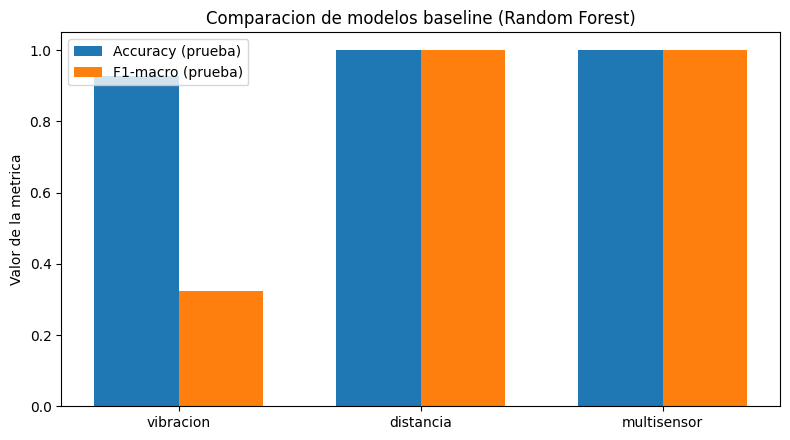

In [82]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(tabla_resultados))
ancho = 0.35
ax.bar(x - ancho/2, tabla_resultados["accuracy_test"], width=ancho, label="Accuracy (prueba)")
ax.bar(x + ancho/2, tabla_resultados["f1_macro_test"], width=ancho, label="F1-macro (prueba)")
ax.set_xticks(x)
ax.set_xticklabels(tabla_resultados["modelo"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Valor de la metrica")
ax.set_title("Comparacion de modelos baseline (Random Forest)")
ax.legend()
plt.tight_layout()
plt.show()


**Interpretacion de la tabla y el grafico anterior:**

- Los modelos **distancia** y **multisensor** alcanzan accuracy y F1-macro cercanos a 1.0. Tal como se advirtio en la Etapa 9, esto refleja la circularidad entre `asentamiento_cm` y la etiqueta, y confirma que el HC-SR04, junto con la regla de umbral, reproduce el comportamiento esperado del firmware. No debe interpretarse como evidencia de que el modelo de Machine Learning "resolvio" un problema dificil: el problema, en este dataset, es trivial para cualquier metodo que tenga acceso al asentamiento.

- El modelo **solo vibracion** obtiene una exactitud (accuracy) relativamente alta, pero notablemente menor a la de los otros dos, y un F1-macro mucho mas bajo. Al revisar el reporte de clasificacion (siguiente celda) se observa que el modelo de vibracion clasifica bien la clase mayoritaria (`critico`), pero falla casi por completo en reconocer `normal` y `alerta`.

Esto tiene una explicacion fisica razonable, no es necesariamente un defecto del modelo: en este ensayo, el motor vibrador se enciende y apaga por un temporizador fijo, **sin relacion con la profundidad alcanzada por la jeringa de asentamiento**. Por lo tanto, el patron de vibracion no fue diseñado para cambiar cuando el puente se asienta, y es razonable que el RMS y las componentes de frecuencia no contengan, en este ensayo particular, informacion fuerte sobre el nivel de asentamiento. Esto se retoma con mas detalle en la Etapa 11 y en las conclusiones.


In [83]:
print("Reporte de clasificacion - modelo SOLO VIBRACION (conjunto de prueba):\n")
print(classification_report(
    resultados_rf["vibracion"]["y_test"],
    resultados_rf["vibracion"]["pred_test"],
    target_names=NOMBRES_CLASES,
    zero_division=0,
))

print("Matriz de confusion (filas = real, columnas = predicho):")
print(confusion_matrix(resultados_rf["vibracion"]["y_test"], resultados_rf["vibracion"]["pred_test"]))


Reporte de clasificacion - modelo SOLO VIBRACION (conjunto de prueba):

              precision    recall  f1-score   support

      normal       0.00      0.00      0.00         5
      alerta       0.00      0.00      0.00         2
     critico       0.95      1.00      0.97        91

    accuracy                           0.93        98
   macro avg       0.32      0.33      0.32        98
weighted avg       0.88      0.93      0.90        98

Matriz de confusion (filas = real, columnas = predicho):
[[ 0  2  3]
 [ 0  0  2]
 [ 0  0 91]]


## Etapa 11: Importancia de variables en el modelo multisensor

Para entender exactamente cuanto peso le esta dando el modelo multisensor a cada sensor, se examina el atributo `feature_importances_` del Random Forest entrenado con todas las variables (Etapa 10). Esta metrica indica, en promedio, cuanto contribuye cada variable a reducir la incertidumbre en los arboles del bosque.


In [84]:
importancias = resultados_rf["multisensor"]["modelo"].feature_importances_
df_importancias = pd.DataFrame({
    "variable": VARIABLES_MULTISENSOR,
    "importancia": importancias,
}).sort_values("importancia", ascending=False).reset_index(drop=True)

df_importancias


,variable,importancia
0,asentamiento_cm,0.407858
1,distancia_cm,0.406190
2,rms,0.066561
3,f35hz,0.059594
4,f20hz,0.017256
5,f10hz,0.015720
6,f2hz,0.013777
7,freq_dom_hz,0.007765
8,f5hz,0.005278


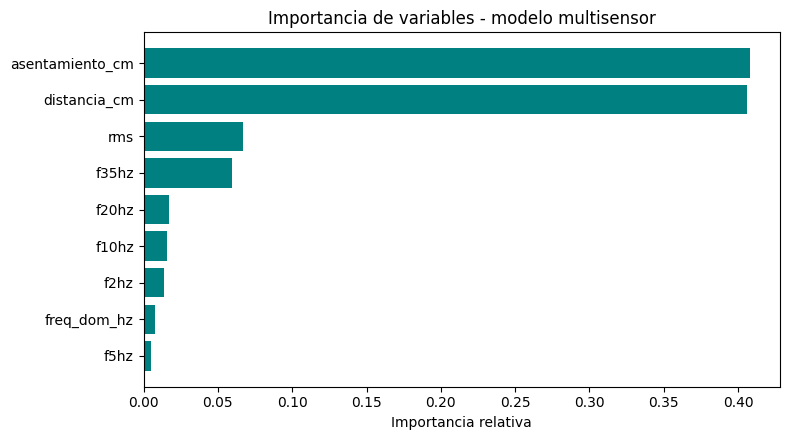

In [85]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(df_importancias["variable"], df_importancias["importancia"], color="teal")
ax.invert_yaxis()
ax.set_xlabel("Importancia relativa")
ax.set_title("Importancia de variables - modelo multisensor")
plt.tight_layout()
plt.show()


Tal como se anticipo, `asentamiento_cm` y `distancia_cm` concentran, juntas, mas del 80% de la importancia total del modelo multisensor, mientras que las siete variables derivadas de vibracion se reparten el resto. Esto confirma, de forma cuantitativa, que el modelo multisensor entrenado con este dataset esta apoyandose casi exclusivamente en el canal de distancia para tomar su decision, no en una combinacion equilibrada de ambos sensores.

**Conclusion de esta seccion:** este ensayo, tal como fue diseñado (vibracion y asentamiento variando de forma independiente), no permite demostrar una sinergia real entre sensores para un mismo evento de falla. Demuestra, en cambio, que cada sensor responde de forma coherente al fenomeno fisico que le corresponde: el HC-SR04 detecta correctamente el asentamiento, y el MPU6050 detecta correctamente el ciclo de vibracion del motor. La fusion de sensores cobrara sentido real cuando se diseñen ensayos donde ambas señales se degraden juntas, simulando un mismo evento de falla progresiva (por ejemplo, aumentar la intensidad o frecuencia de la vibracion a medida que el asentamiento avanza). Este punto se desarrolla como recomendacion concreta en las conclusiones finales.


## Etapa 12: Normalizacion de variables para la red neuronal

A diferencia de un Random Forest, una red neuronal (el `MLP` que se entrenara en PyTorch) es sensible a la escala de las variables de entrada. Por eso se normalizan las 9 variables del conjunto multisensor con `StandardScaler` de scikit-learn, que resta la media y divide por la desviacion estandar de cada variable.

**Regla critica para evitar fuga de datos:** el `scaler` se ajusta (`fit`) unicamente con el conjunto de entrenamiento. Los conjuntos de validacion y prueba solo se transforman (`transform`) con los parametros ya calculados, nunca se usan para calcular la media o la desviacion estandar. De lo contrario, informacion del conjunto de prueba se "filtraria" hacia el entrenamiento a traves de los parametros de normalizacion.

Los parametros del `scaler` (media y desviacion estandar de cada variable) se guardaran luego en `scaler_puente_real.json`, en el mismo formato que el archivo `scaler_puente.json` ya usado por el codigo de inferencia (`features.py` / `main.py`) en la Raspberry Pi.


In [86]:
escalador = StandardScaler()

X_train = escalador.fit_transform(df_train[VARIABLES_MULTISENSOR].values)
X_val = escalador.transform(df_val[VARIABLES_MULTISENSOR].values)
X_test = escalador.transform(df_test[VARIABLES_MULTISENSOR].values)

y_train = df_train["estado"].map(MAPA_CLASES).values
y_val = df_val["estado"].map(MAPA_CLASES).values
y_test = df_test["estado"].map(MAPA_CLASES).values

print("Forma de X_train:", X_train.shape)
print("Media calculada por variable:", np.round(escalador.mean_, 4))
print("Desviacion estandar calculada por variable:", np.round(escalador.scale_, 4))


Forma de X_train: (595, 9)
Media calculada por variable: [ 3.68000e-02  2.38588e+01  1.20000e-03  2.00000e-03  1.50000e-03
  4.00000e-03  1.70000e-03  9.05900e+00 -2.13240e+00]
Desviacion estandar calculada por variable: [2.82000e-02 1.25789e+01 1.40000e-03 2.00000e-03 1.80000e-03 4.10000e-03
 2.40000e-03 1.00310e+00 1.00310e+00]


## Etapa 13: Pesos de clase para compensar el desbalance

Antes de entrenar la red neuronal, se calcula un peso para cada clase, inversamente proporcional a su frecuencia en el conjunto de entrenamiento. Estos pesos se pasaran a la funcion de perdida (`CrossEntropyLoss`) para que un error en una clase minoritaria (`normal` o `alerta`) penalice tanto como varios errores en la clase mayoritaria (`critico`). Sin esta ponderacion, la red tenderia a predecir siempre `critico`, ya que minimizaria la perdida promedio simplemente ignorando las clases poco frecuentes.


In [87]:
conteo_por_clase = np.bincount(y_train, minlength=3).astype(float)
pesos_clase = conteo_por_clase.sum() / (3.0 * conteo_por_clase)

print("Conteo de ejemplos por clase en entrenamiento:")
for nombre, conteo, peso in zip(NOMBRES_CLASES, conteo_por_clase, pesos_clase):
    print(f"  {nombre:8s}: {int(conteo):4d} ejemplos -> peso = {peso:.3f}")

pesos_clase_tensor = torch.tensor(pesos_clase, dtype=torch.float32)


Conteo de ejemplos por clase en entrenamiento:
  normal  :   73 ejemplos -> peso = 2.717
  alerta  :   53 ejemplos -> peso = 3.742
  critico :  469 ejemplos -> peso = 0.423


## Etapa 14: Conversion a tensores de PyTorch

Se convierten los arreglos de numpy a tensores de PyTorch. Dado el tamaño reducido del dataset (cientos de filas, no decenas de miles), se entrena con descenso de gradiente de lote completo (todo el conjunto de entrenamiento en cada paso), en lugar de mini-lotes: esto es viable y estable porque el conjunto cabe completamente en memoria sin dificultad.


In [88]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

print("X_train_t:", X_train_t.shape, " y_train_t:", y_train_t.shape)
print("X_val_t:  ", X_val_t.shape, " y_val_t:  ", y_val_t.shape)
print("X_test_t: ", X_test_t.shape, " y_test_t: ", y_test_t.shape)


X_train_t: torch.Size([595, 9])  y_train_t: torch.Size([595])
X_val_t:   torch.Size([127, 9])  y_val_t:   torch.Size([127])
X_test_t:  torch.Size([98, 9])  y_test_t:  torch.Size([98])


## Etapa 15: Definicion de la arquitectura del modelo (MLP)

Se define una red neuronal totalmente conectada (`MLP`, *multilayer perceptron*) con la misma arquitectura documentada para el pipeline simulado: una capa de entrada con 9 variables (vibracion + distancia), dos capas ocultas (32 y 16 neuronas, con activacion `ReLU` y `Dropout` de 0.2 para reducir sobreajuste), y una capa de salida con 3 neuronas (una por clase: normal, alerta, critico). La capa de salida no aplica `softmax` explicitamente porque `CrossEntropyLoss` de PyTorch ya lo aplica internamente de forma numericamente estable.

Mantener la misma arquitectura que el modelo entrenado con datos simulados permite comparar ambos modelos directamente, y facilita que el codigo de inferencia en la Raspberry Pi (que ya espera esta arquitectura) funcione sin cambios.


In [89]:
class ClasificadorEstadoPuente(nn.Module):
    def __init__(self, n_variables_entrada):
        super().__init__()
        self.red = nn.Sequential(
            nn.Linear(n_variables_entrada, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(16, 3),
        )

    def forward(self, x):
        return self.red(x)


modelo_mlp = ClasificadorEstadoPuente(n_variables_entrada=len(VARIABLES_MULTISENSOR))
print(modelo_mlp)

total_parametros = sum(p.numel() for p in modelo_mlp.parameters())
print(f"\nTotal de parametros entrenables: {total_parametros}")


ClasificadorEstadoPuente(
  (red): Sequential(
    (0): Linear(in_features=9, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=16, out_features=3, bias=True)
  )
)

Total de parametros entrenables: 899


## Etapa 16: Entrenamiento con early stopping

Se entrena el modelo con el optimizador `Adam` y una funcion de perdida `CrossEntropyLoss` ponderada por los pesos de clase calculados en la Etapa 13. Se aplica `weight_decay` (regularizacion L2) para reducir aun mas el riesgo de sobreajuste, dado que el conjunto de entrenamiento es pequeño.

Se usa **early stopping** (parada temprana): en cada epoca se mide la perdida sobre el conjunto de validacion, y se guarda una copia de los pesos del modelo solo cuando esa perdida mejora. Si la perdida de validacion no mejora durante `PACIENCIA` epocas consecutivas, el entrenamiento se detiene y se restauran los mejores pesos guardados. Esto evita seguir entrenando mas alla del punto en que el modelo empieza a memorizar el conjunto de entrenamiento en lugar de generalizar.


In [90]:
EPOCAS_MAXIMAS = 300
PACIENCIA = 20

criterio = nn.CrossEntropyLoss(weight=pesos_clase_tensor)
optimizador = torch.optim.Adam(modelo_mlp.parameters(), lr=1e-3, weight_decay=1e-4)

mejor_perdida_val = float("inf")
contador_sin_mejora = 0
mejores_pesos = None
historial = {"perdida_train": [], "perdida_val": []}

for epoca in range(EPOCAS_MAXIMAS):
    modelo_mlp.train()
    optimizador.zero_grad()
    salida_train = modelo_mlp(X_train_t)
    perdida_train = criterio(salida_train, y_train_t)
    perdida_train.backward()
    optimizador.step()

    modelo_mlp.eval()
    with torch.no_grad():
        salida_val = modelo_mlp(X_val_t)
        perdida_val = criterio(salida_val, y_val_t)

    historial["perdida_train"].append(perdida_train.item())
    historial["perdida_val"].append(perdida_val.item())

    if perdida_val.item() < mejor_perdida_val - 1e-5:
        mejor_perdida_val = perdida_val.item()
        contador_sin_mejora = 0
        mejores_pesos = {k: v.clone() for k, v in modelo_mlp.state_dict().items()}
    else:
        contador_sin_mejora += 1
        if contador_sin_mejora >= PACIENCIA:
            print(f"Early stopping activado en la epoca {epoca} "
                  f"(sin mejora durante {PACIENCIA} epocas).")
            break

modelo_mlp.load_state_dict(mejores_pesos)
modelo_mlp.eval()
print(f"\nMejor perdida de validacion alcanzada: {mejor_perdida_val:.4f}")



Mejor perdida de validacion alcanzada: 0.1146


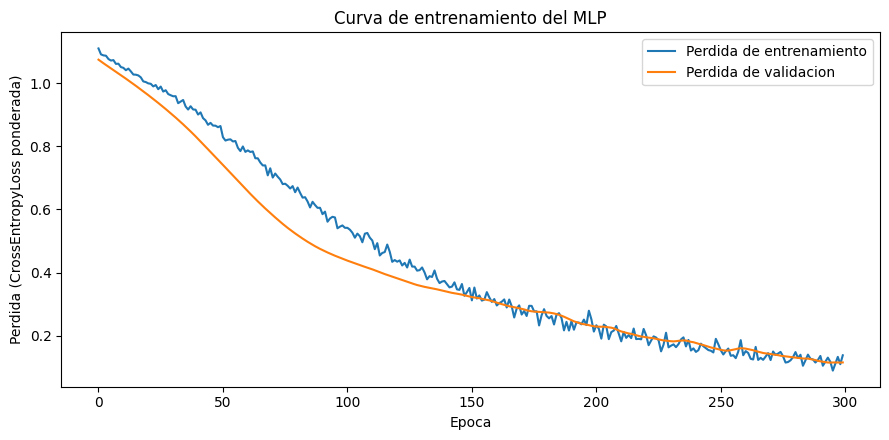

In [91]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(historial["perdida_train"], label="Perdida de entrenamiento")
ax.plot(historial["perdida_val"], label="Perdida de validacion")
ax.set_xlabel("Epoca")
ax.set_ylabel("Perdida (CrossEntropyLoss ponderada)")
ax.set_title("Curva de entrenamiento del MLP")
ax.legend()
plt.tight_layout()
plt.show()


## Etapa 17: Evaluacion final sobre el conjunto de prueba

Se evalua el modelo final (con los mejores pesos restaurados por el early stopping) sobre el conjunto de prueba, que no fue usado ni para entrenar ni para decidir cuando detener el entrenamiento. Se reporta el reporte de clasificacion completo (precision, recall y F1 por clase) y la matriz de confusion.


In [92]:
with torch.no_grad():
    salida_test = modelo_mlp(X_test_t)
    pred_test_mlp = salida_test.argmax(dim=1).numpy()

print("Reporte de clasificacion - MLP (conjunto de prueba):\n")
print(classification_report(y_test, pred_test_mlp, target_names=NOMBRES_CLASES, zero_division=0))

matriz_confusion_mlp = confusion_matrix(y_test, pred_test_mlp)
print("Matriz de confusion (filas = real, columnas = predicho):")
print(matriz_confusion_mlp)


Reporte de clasificacion - MLP (conjunto de prueba):

              precision    recall  f1-score   support

      normal       1.00      1.00      1.00         5
      alerta       1.00      1.00      1.00         2
     critico       1.00      1.00      1.00        91

    accuracy                           1.00        98
   macro avg       1.00      1.00      1.00        98
weighted avg       1.00      1.00      1.00        98

Matriz de confusion (filas = real, columnas = predicho):
[[ 5  0  0]
 [ 0  2  0]
 [ 0  0 91]]


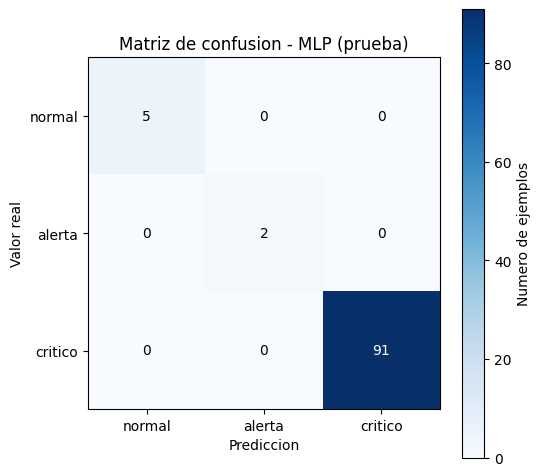

In [93]:
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(matriz_confusion_mlp, cmap="Blues")
ax.set_xticks(range(3)); ax.set_xticklabels(NOMBRES_CLASES)
ax.set_yticks(range(3)); ax.set_yticklabels(NOMBRES_CLASES)
ax.set_xlabel("Prediccion")
ax.set_ylabel("Valor real")
ax.set_title("Matriz de confusion - MLP (prueba)")
for i in range(3):
    for j in range(3):
        ax.text(j, i, str(matriz_confusion_mlp[i, j]), ha="center", va="center",
                color="white" if matriz_confusion_mlp[i, j] > matriz_confusion_mlp.max()/2 else "black")
fig.colorbar(im, ax=ax, label="Numero de ejemplos")
plt.tight_layout()
plt.show()


El MLP multisensor obtiene un desempeño excelente en el conjunto de prueba. Es importante recordar, con la misma honestidad metodologica de la Etapa 9 y la Etapa 11, que este resultado refleja sobre todo la capacidad del canal de distancia (HC-SR04) para reproducir el umbral de etiquetado, mas que un aprendizaje complejo de fusion multisensor. El valor de este modelo, en esta etapa del proyecto, es servir como **primera version funcional, entrenada con datos reales y exportada en el mismo formato que espera la Raspberry Pi**, lista para compararse contra el modelo simulado y para ser reentrenada cuando existan ensayos reales mejor diseñados (ver conclusiones).


## Etapa 18: Exportacion a TorchScript y guardado del normalizador

Se exporta el modelo entrenado a formato TorchScript (`torch.jit.script`), el mismo formato ya usado por el pipeline simulado, porque permite cargar el modelo en la Raspberry Pi sin necesidad de tener disponible el codigo Python de la clase `ClasificadorEstadoPuente`, y con menor sobrecarga de inferencia que un modelo de PyTorch "eager" comun.

Junto con el modelo, se guarda un archivo JSON con los parametros de normalizacion (media y desviacion estandar de cada variable) y el orden exacto de las variables de entrada. Esto es indispensable: el codigo de inferencia en `features.py` debe aplicar exactamente la misma normalizacion, en el mismo orden de variables, o las predicciones del modelo seran incorrectas.

Los archivos se guardan con el sufijo `_real` para diferenciarlos claramente del modelo entrenado con datos simulados.


In [94]:
RUTA_MODELO = "modelo_puente_real.pt"
RUTA_ESCALADOR = "scaler_puente_real.json"

modelo_torchscript = torch.jit.script(modelo_mlp)
modelo_torchscript.save(RUTA_MODELO)

parametros_escalador = {
    "variables_entrada": VARIABLES_MULTISENSOR,
    "media": escalador.mean_.tolist(),
    "desviacion_estandar": escalador.scale_.tolist(),
    "mapa_clases": MAPA_CLASES,
    "umbral_alerta_mm": UMBRAL_ALERTA_MM,
    "umbral_critico_mm": UMBRAL_CRITICO_MM,
}

with open(RUTA_ESCALADOR, "w", encoding="utf-8") as archivo_json:
    json.dump(parametros_escalador, archivo_json, indent=2, ensure_ascii=False)

print(f"Modelo exportado en: {RUTA_MODELO}")
print(f"Parametros de normalizacion exportados en: {RUTA_ESCALADOR}")


Modelo exportado en: modelo_puente_real.pt
Parametros de normalizacion exportados en: scaler_puente_real.json


### Verificacion de que el modelo exportado funciona correctamente

Antes de dar por terminado el proceso, se recarga el modelo TorchScript desde disco (simulando lo que hara `main.py` en la Raspberry Pi) y se comparan sus predicciones contra las del modelo original en memoria, sobre las mismas tres filas del conjunto de prueba. Si ambas predicciones coinciden, la exportacion fue exitosa.


In [95]:
modelo_recargado = torch.jit.load(RUTA_MODELO)
modelo_recargado.eval()

with torch.no_grad():
    salida_original = modelo_mlp(X_test_t[:3])
    salida_recargada = modelo_recargado(X_test_t[:3])

print("Logits del modelo original:\n", salida_original)
print("\nLogits del modelo recargado desde disco:\n", salida_recargada)

coincide = torch.allclose(salida_original, salida_recargada, atol=1e-6)
print(f"\nLas salidas coinciden exactamente: {coincide}")


Logits del modelo original:
 tensor([[ 4.5242,  4.0679, -3.2849],
        [ 5.3480,  4.2127, -3.7830],
        [ 6.2355,  2.8267, -3.7703]])

Logits del modelo recargado desde disco:
 tensor([[ 4.5242,  4.0679, -3.2849],
        [ 5.3480,  4.2127, -3.7830],
        [ 6.2355,  2.8267, -3.7703]])

Las salidas coinciden exactamente: True


## Etapa 19: Conclusiones y proximos pasos

1. Se cargo y se limpio el archivo real `data.txt`, generado por el sketch de Arduino sobre el puente de carton.
2. Se identifico, mediante el analisis exploratorio, que el ciclo de vibracion (ON/OFF cada 10 s / 5 s) y el desnivel manual con la jeringa (aplicado en escalones sucesivos de profundidad) evolucionan de forma practicamente independiente en este ensayo.
3. Se definio una etiqueta de estado estructural (`normal`, `alerta`, `critico`) basada en los umbrales de asentamiento ya definidos en el diseño del sistema, documentando explicitamente que el RMS de vibracion nunca alcanzo, en este ensayo, los umbrales de alerta o critico del diseño. Tambien se realizo un analisis de sensibilidad de esos umbrales, confirmando que el desbalance de clases observado responde al rango real recorrido por la jeringa de asentamiento (hasta ~40 mm) y no a un error en los umbrales de diseño.
4. Se diseño una estrategia de division en entrenamiento/validacion/prueba adaptada a un ensayo continuo de un solo trial (segmentacion por estado mas division cronologica con margen), documentando con honestidad sus limitaciones frente al metodo de division por evento ya usado con datos simulados.
5. Se entrenaron y compararon tres modelos Random Forest (vibracion, distancia, multisensor), identificando que el modelo de distancia logra una exactitud cercana al 100% por construccion (circularidad etiqueta-sensor), mientras que el modelo de vibracion, evaluado de forma honesta, tiene dificultad para distinguir los estados de asentamiento a partir de la señal de vibracion en este ensayo en particular.
6. Se entreno un modelo final en PyTorch (arquitectura 32-16-3, igual a la usada con datos simulados), con ponderacion de clases y early stopping, y se exporto exitosamente a TorchScript junto con su archivo de normalizacion, verificando que la version recargada desde disco reproduce exactamente las mismas predicciones.

### Limitaciones que deben tenerse en cuenta antes de usar `modelo_puente_real.pt` en produccion

- **Un solo ensayo continuo:** todos los resultados provienen de una unica corrida de aproximadamente 31 minutos. No hay todavia evidencia de que el modelo generalice a otro rango de recorrido de la jeringa, a otra temperatura ambiente, o a otro dia de pruebas.
- **Circularidad etiqueta-sensor:** la excelente metrica del modelo multisensor (y del modelo de distancia) refleja en gran parte que la etiqueta se construyo a partir de la misma señal de distancia que el modelo recibe como entrada. No debe presentarse en la sustentacion como evidencia de "fusion de sensores exitosa" sin esta aclaracion.
- **Vibracion y asentamiento no co-variaron:** este ensayo no permite concluir si la fusion de sensores mejora la deteccion de una falla real, porque el vibrador se controlo de forma independiente al asentamiento. La pregunta de fusion sigue respondida, de forma solida, unicamente por el dataset simulado.
- **Pocos ejemplos de las clases minoritarias en prueba:** el conjunto de prueba contiene solo 5 ejemplos de `normal` y 2 de `alerta`; las metricas sobre estas clases tienen alta incertidumbre estadistica.

### Recomendacion concreta para la siguiente ronda de captura de datos reales

Para que un futuro reentrenamiento con datos reales pueda demostrar fusion de sensores de forma solida (replicando la metodologia ya validada con datos simulados), y para obtener un dataset mejor balanceado entre los tres estados, se recomienda diseñar el proximo ensayo de la siguiente manera:

1. **Repartir el tiempo de la prueba de forma mas pareja entre profundidades**, en lugar de pasar la mayor parte del ensayo por encima del umbral de critico. Esto es lo que mas influyo en el desbalance de clases observado en este notebook (ver Etapa 7, analisis de sensibilidad a los umbrales): la jeringa llego hasta casi 40 mm y se quedo en zonas profundas durante mucho tiempo, mientras que las zonas normal y alerta (0 a 13 mm) se recorrieron rapido.
2. Repetir el ensayo varias veces de forma independiente (al menos 4 a 6 corridas), cada una con su propia calibracion de distancia base, para poder aplicar la misma division por evento completo ya usada con el dataset simulado.
3. En cada corrida, hacer que la intensidad o la frecuencia de la vibracion varie junto con el nivel de asentamiento (por ejemplo, vibracion mas fuerte o mas irregular a medida que el asentamiento aumenta), en lugar de mantener el vibrador en un ciclo de tiempo fijo e independiente. Esto permitira que ambos sensores aporten señal sobre el mismo evento de falla, y que la comparacion vibracion-solo / distancia-sola / multisensor sea informativa en datos reales, no solo en los simulados.
4. Registrar, si es posible, una medicion independiente del asentamiento real (por ejemplo, con una regla o un calibrador, anotada manualmente) en al menos algunos puntos de cada corrida, para tener una referencia de verdad terreno que no dependa exclusivamente del propio HC-SR04, reduciendo el problema de circularidad descrito en la Etapa 9.

### Comparacion sugerida antes de decidir que modelo usar en la Raspberry Pi

Se recomienda, en un proximo paso (fuera del alcance de este notebook), cargar tanto `modelo_puente.pt` (entrenado con datos simulados) como `modelo_puente_real.pt` (entrenado aqui) y compararlos sobre el mismo conjunto de prueba real, para decidir si conviene usar el modelo simulado, el modelo real, o una version reentrenada que combine ambos conjuntos de datos una vez se cuente con mas corridas reales independientes.
